In [45]:
import numpy as np
import pandas as pd
from scipy.stats import skew
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns



In [46]:
# Ustawienie losowości (powtarzalność wyników) - zeby zawsze dostac te same liczby kiedy bedziemy runowac 
np.random.seed(42)

In [47]:
# Parametry rozkładu normalnego
mean = 3
std_dev = 1

In [48]:
# Generowanie danych
data_100 = np.random.normal(mean, std_dev, 100)
data_10000 = np.random.normal(mean, std_dev, 10000)

In [49]:
# liczenie statystyk opisowych

In [83]:
def descriptive_stats(data):

    q0 = np.min(data)
    q1 = np.percentile(data, 25)
    q2 = np.median(data)
    q3 = np.percentile(data, 75)
    q4 = np.max(data)

    iqr = q3 - q1

    df = pd.DataFrame({
        "Średnia": [np.mean(data)],
        "Mediana": [q2],
        "Odchylenie standardowe": [np.std(data, ddof=1)],
        "Wariancja": [np.var(data, ddof=1)],
        "Skośność": [skew(data)],
        "Zakres": [q4 - q0],
        "IQR": [iqr],
        "Q0 (min)": [q0],
        "Q1": [q1],
        "Q2 (mediana)": [q2],
        "Q3": [q3],
        "Q4 (max)": [q4]
    })

    return df


In [84]:
# prezentacja wizualna

In [85]:
def plot_stats(data):

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Histogram
    sns.histplot(data, bins=30, kde=True, ax=axes[0])
    axes[0].set_title("Histogram rozkładu")
    axes[0].set_xlabel("Wartości")
    axes[0].set_ylabel("Częstość")

    # Box plot
    sns.boxplot(x=data, ax=axes[1])
    axes[1].set_title("Box plot (wykres pudełkowy)")
    axes[1].set_xlabel("Wartości")

    plt.tight_layout()
    plt.show()

data_100


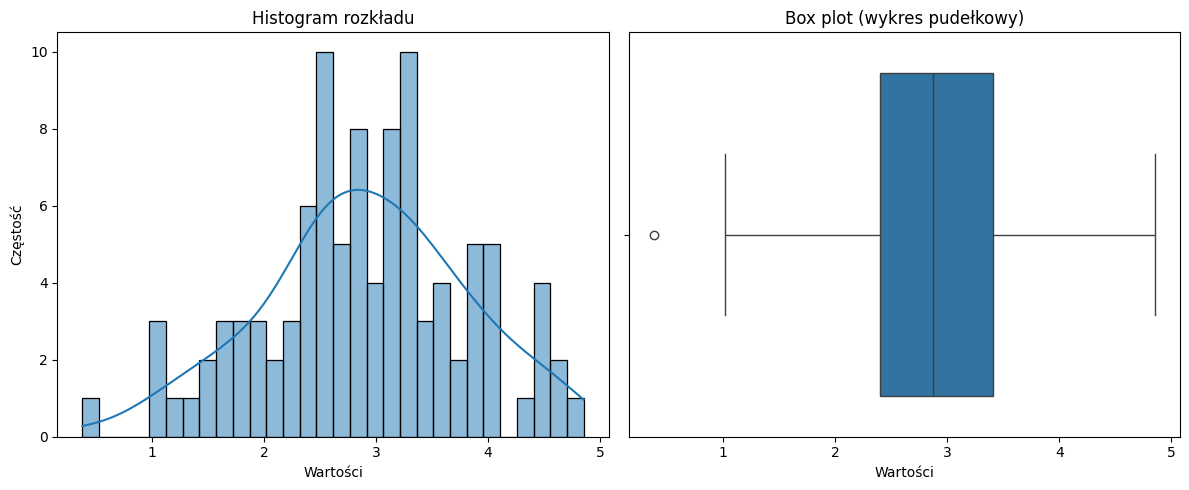

In [86]:
print("data_100")
plot_stats(data_100)

data_10000


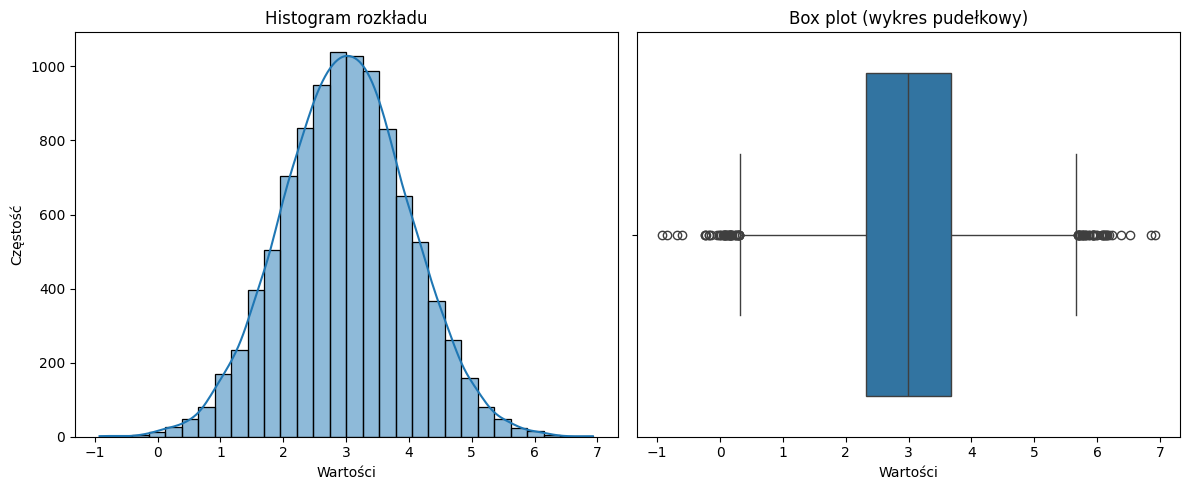

In [87]:
print("data_10000")
plot_stats(data_10000)

In [88]:
descriptive_stats(data_100)

,Średnia,Mediana,Odchylenie standardowe,Wariancja,Skośność,Zakres,IQR,Q0 (min),Q1,Q2 (mediana),Q3,Q4 (max)
0,2.896153,2.873044,0.908168,0.82477,-0.175268,4.472023,1.006858,0.380255,2.399094,2.873044,3.405952,4.852278


In [89]:
descriptive_stats(data_10000)

,Średnia,Mediana,Odchylenie standardowe,Wariancja,Skośność,Zakres,IQR,Q0 (min),Q1,Q2 (mediana),Q3,Q4 (max)
0,2.998821,2.998835,1.003741,1.007497,0.002161,7.848638,1.345597,-0.9224,2.326435,2.998835,3.672032,6.926238


# wnioski

Im większa próba, tym wyniki są bliższe temu, czego oczekujemy dla rozkładu normalnego. Przy 100 obserwacjach widać odchylenia – średnia =2.90 , mediana- 2.87 czy skośność -0.18. Przy 10 000 danych wszystko się stabilizuje: średnia i mediana są bliskie 3, skośność prawie zerowa, a wariancja bliska 1. Widać też, że większa próba daje większy zakres, bo łatwiej trafić na wartości skrajne, ale środek danych (kwartyle i IQR) pozostaje dość stabilny.